# Setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import os
from datetime import datetime

# Folder containing the CSV exports from "Strain Simulation FEniCSx.ipynb".
# All coordinates in these files are already in the exported convention:
# x = mesh_x - 1.25, y = mesh_y - 108.05, z = -z_mesh - 13 (Ge well: z = 42-58).
SIM_DIR = "simulation_2026-09-08"

# All PDF graphs are saved into graph/<date>/ (created if missing)
GRAPH_DIR = os.path.join("graph", datetime.now().strftime("%Y-%m-%d"))
os.makedirs(GRAPH_DIR, exist_ok=True)

# Displacement

In [21]:
# Load the CSV file into a DataFrame. The coordinates in this file already
# have the shift applied to the DATA (x = mesh_x - 1.25, y = mesh_y - 108.05);
# the slice z is constant and recorded in the export's metadata.json
# (exported convention z = -z_mesh - 13). Do NOT shift the data again here.
df = pd.read_csv(f"{SIM_DIR}/displacement/displacement_data.csv")

# Reshape X, Y, and displacement components for plotting
num_x = len(df['X'].unique())
num_y = len(df['Y'].unique())
X = df['X'].values.reshape((num_x, num_y))
Y = df['Y'].values.reshape((num_x, num_y))
displacement_x = df['displacement_x'].values.reshape((num_x, num_y))
displacement_y = df['displacement_y'].values.reshape((num_x, num_y))
displacement_z = df['displacement_z'].values.reshape((num_x, num_y))

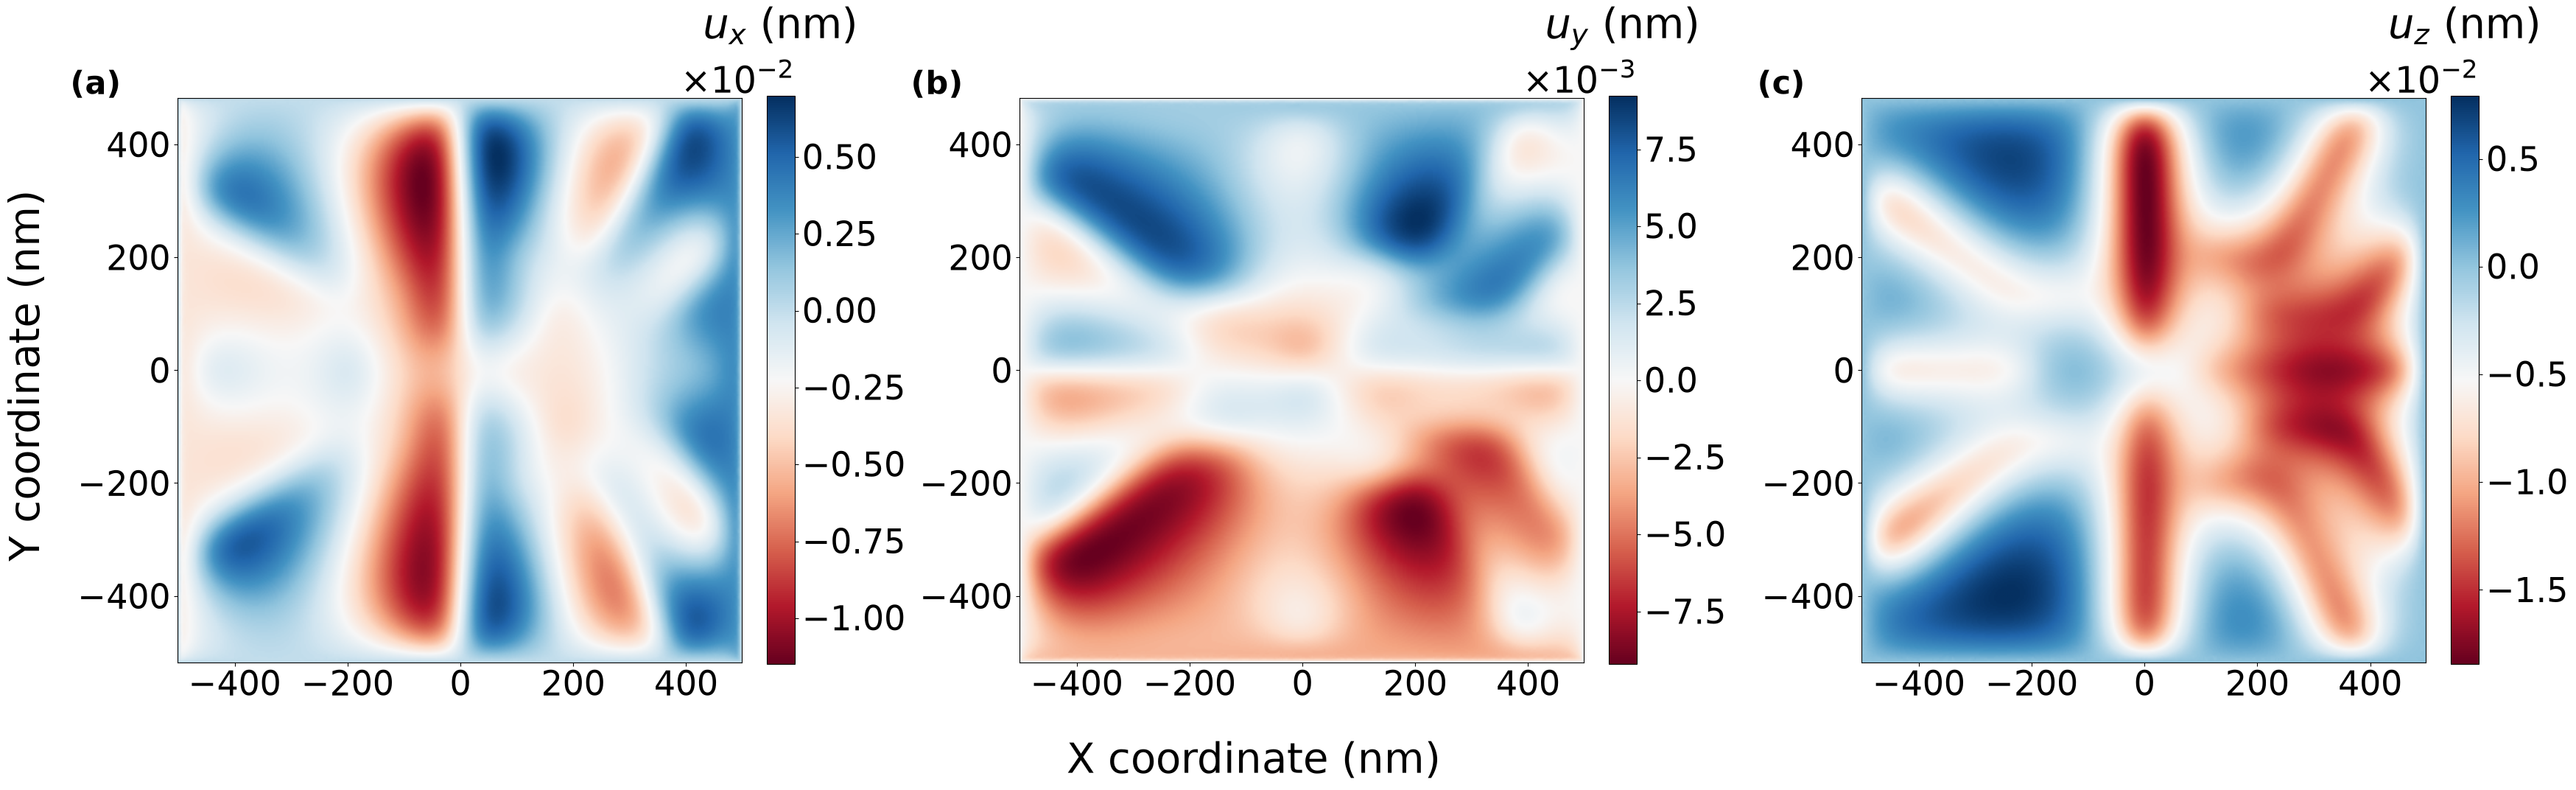

In [22]:
# Define a function to format the colorbar and place the label at the top
def format_colorbar(cbar, label):
    cbar.ax.tick_params(labelsize=33)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_scientific(True)
    formatter.set_powerlimits((-2, 2))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.yaxis.offsetText.set_fontsize(35)  # Increase font size for the exponent
    # Place the label at the top of the colorbar using LaTeX-style notation
    cbar.ax.set_title(label, fontsize=40, pad=20, loc='center')

# Define data for each subplot
displacement_data = [displacement_x, displacement_y, displacement_z]
colorbar_labels = [r'$u_x$ (nm)', r'$u_y$ (nm)', r'$u_z$ (nm)']
subplot_labels = ['(a)', '(b)', '(c)']

# Set up a 1x3 grid of subplots
fig, axes = plt.subplots(1, 3, figsize=(36, 11))

# Loop through each subplot, plotting data and adding labels
for i, (ax, data, cbar_label, subplot_label) in enumerate(zip(axes, displacement_data, colorbar_labels, subplot_labels)):
    # Plot the displacement component
    contour = ax.imshow(data, extent=[X.min(), X.max(), Y.min(), Y.max()],
                        origin='lower', aspect='auto', cmap='RdBu')
    ax.tick_params(axis='both', which='major', labelsize=33)
    cbar = fig.colorbar(contour, ax=ax, fraction=0.046, pad=0.04)
    format_colorbar(cbar, cbar_label)

    # Add subplot label (a), (b), etc.
    ax.text(-0.1, 1.05, subplot_label, transform=ax.transAxes, fontsize=31, fontweight='bold', va='top', ha='right')

    # Set aspect ratio
    ax.set_aspect('equal', 'box')

# Adjust shared labels for the entire figure
fig.text(0.5, 0.01, 'X coordinate (nm)', ha='center', fontsize=40)
fig.text(0.03, 0.5, 'Y coordinate (nm)', va='center', rotation='vertical', fontsize=40)

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 1, 1], h_pad=0, w_pad=0.6)

# Save the figure as a vector image in PDF format
plt.savefig(os.path.join(GRAPH_DIR, 'displacement_components.pdf'), format='pdf', dpi=300)

# Display the plot
plt.show()


# Dependence on Height

In [23]:
# Load the strain data (coordinates in these files are already in the
# exported convention, see SIM_DIR above — no shifting needed)
strain_files = {
    'strain_yymxx': f"{SIM_DIR}/strain_3D/strain_yy-xx_3D.csv",
    'strain_xz': f"{SIM_DIR}/strain_3D/strain_xz_3D.csv",
    'strain_yz': f"{SIM_DIR}/strain_3D/strain_yz_3D.csv",
    'strain_xy': f"{SIM_DIR}/strain_3D/strain_xy_3D.csv",
}

# Load the data into a dictionary of dataframes
strain_data = {name: pd.read_csv(path) for name, path in strain_files.items()}

In [24]:
# The CSV exports store the exported z-convention (z = -z_mesh - 13),
# so the z values are already in the 42-58 nm range of the Ge well.
# (With the old raw exports this cell reversed the z-axis and applied
# the xy shifts: df['y'] -= 108.05, df['x'] -= 1.25, df['z'] = -df['z'] - 13.)

In [25]:
# Define the range of z-coordinates corresponding to the germanium well
z_min, z_max = 42, 58
num_splits = 8

# Calculate the step size for splitting
z_step = (z_max - z_min) / num_splits

# Define the z-coordinate ranges for the subsets
z_ranges = [(z_min + i * z_step, z_min + (i + 1) * z_step) for i in range(num_splits)]

# Initialize a dictionary to store subsets for each strain component
strain_subsets = {name: [] for name in strain_data.keys()}

# Split the data into subsets based on the z-coordinate
for name, df in strain_data.items():
    for z_range in z_ranges:
        z_lower, z_upper = z_range
        subset = df[(df['z'] >= z_lower) & (df['z'] < z_upper)]
        strain_subsets[name].append(subset)

# Display the z-coordinate ranges and corresponding subset sizes
for name, subsets in strain_subsets.items():
    print(f"\nStrain component: {name}")
    for i, (z_range, subset) in enumerate(zip(z_ranges, subsets)):
        print(f"Subset {i + 1}: Z range {z_range}, Number of rows: {len(subset)}")


Strain component: strain_yymxx
Subset 1: Z range (42.0, 44.0), Number of rows: 360000
Subset 2: Z range (44.0, 46.0), Number of rows: 360000
Subset 3: Z range (46.0, 48.0), Number of rows: 270000
Subset 4: Z range (48.0, 50.0), Number of rows: 360000
Subset 5: Z range (50.0, 52.0), Number of rows: 360000
Subset 6: Z range (52.0, 54.0), Number of rows: 270000
Subset 7: Z range (54.0, 56.0), Number of rows: 360000
Subset 8: Z range (56.0, 58.0), Number of rows: 270000

Strain component: strain_xz
Subset 1: Z range (42.0, 44.0), Number of rows: 360000
Subset 2: Z range (44.0, 46.0), Number of rows: 360000
Subset 3: Z range (46.0, 48.0), Number of rows: 270000
Subset 4: Z range (48.0, 50.0), Number of rows: 360000
Subset 5: Z range (50.0, 52.0), Number of rows: 360000
Subset 6: Z range (52.0, 54.0), Number of rows: 270000
Subset 7: Z range (54.0, 56.0), Number of rows: 360000
Subset 8: Z range (56.0, 58.0), Number of rows: 270000

Strain component: strain_yz
Subset 1: Z range (42.0, 44.0)

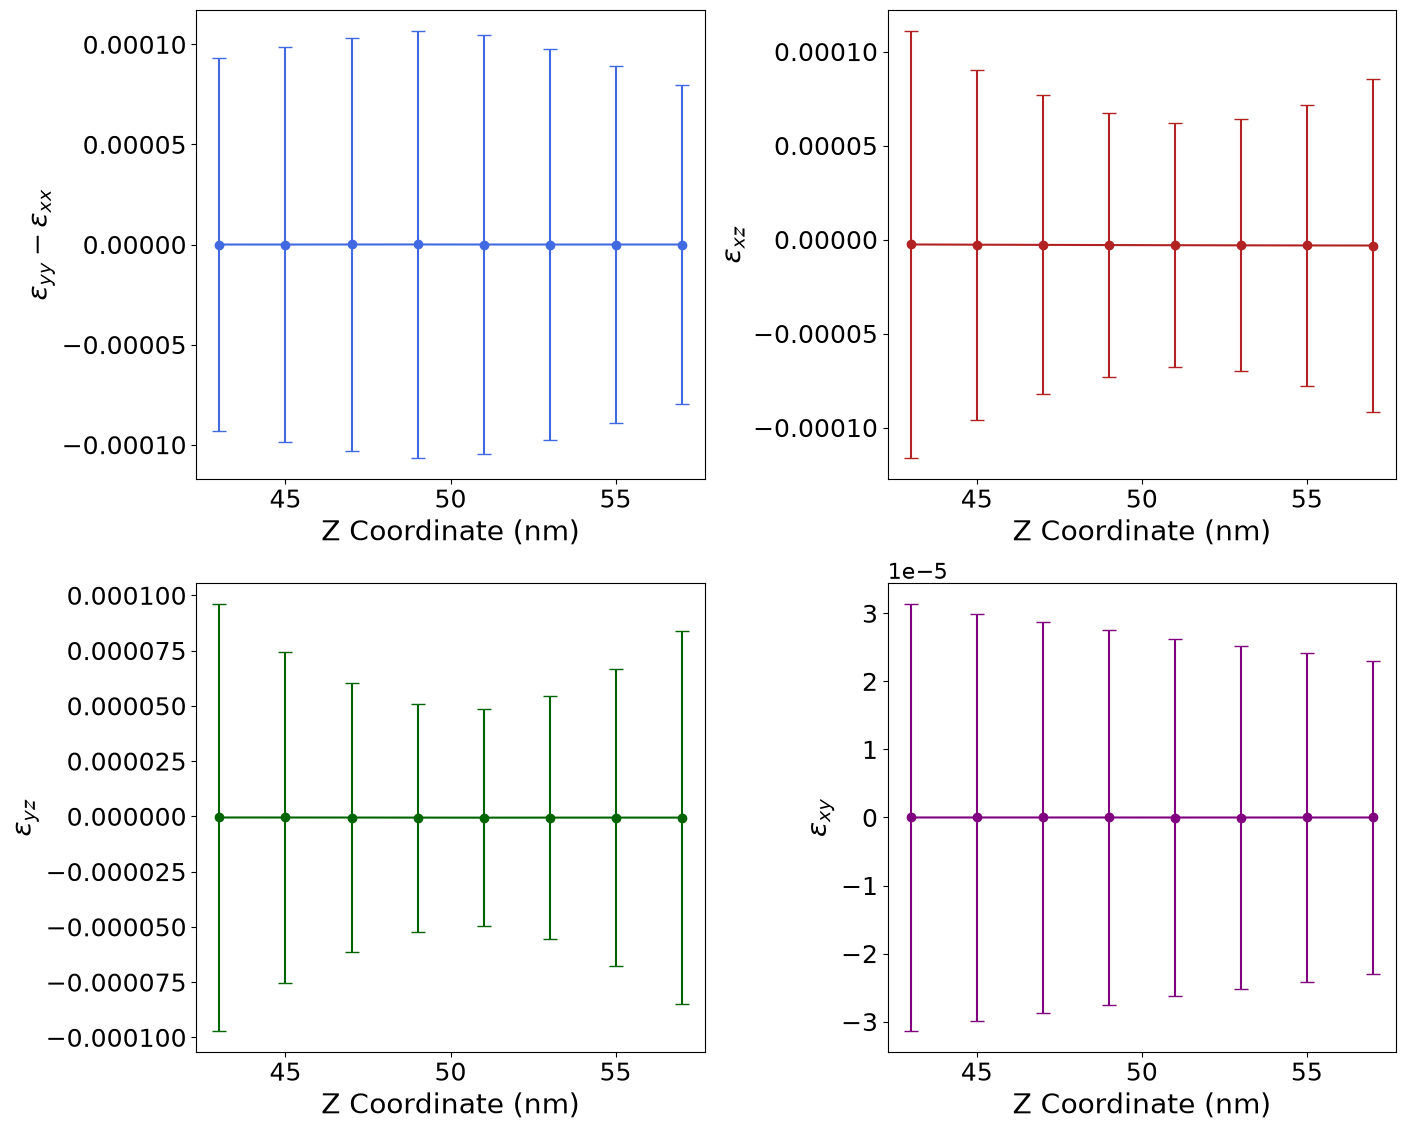

In [26]:
# Variables to control axis label size, tick label size, and scientific notation size
axis_label_size = 20  # Font size for axis labels
tick_label_size = 18  # Font size for tick labels
scientific_notation_size = 16  # Font size for scientific notation text

# Initialize a dictionary to store error bar data
error_bars = {name: {'means': [], 'stds': [], 'z_midpoints': []} for name in strain_data.keys()}

# Compute the means, standard deviations, and midpoints for each subset
for name, subsets in strain_subsets.items():
    for z_range, subset in zip(z_ranges, subsets):
        z_lower, z_upper = z_range
        z_midpoint = (z_lower + z_upper) / 2

        # Compute the mean and standard deviation of the strain values
        mean_value = subset['strain_value'].mean()
        std_value = subset['strain_value'].std()

        # Store the results
        error_bars[name]['means'].append(mean_value)
        error_bars[name]['stds'].append(std_value)
        error_bars[name]['z_midpoints'].append(z_midpoint)

# Create a 2x2 canvas
fig, axs = plt.subplots(2, 2, figsize=(14, 12))

# Define colors for each strain component
colors = {
    'strain_yymxx': 'royalblue',
    'strain_xz': 'firebrick',
    'strain_yz': 'darkgreen',
    'strain_xy': 'purple'
}

# Define y-axis labels for each strain component
y_labels = {
    'strain_yymxx': r'$\epsilon_{yy} - \epsilon_{xx}$',
    'strain_xz': r'$\epsilon_{xz}$',
    'strain_yz': r'$\epsilon_{yz}$',
    'strain_xy': r'$\epsilon_{xy}$'
}

# Flatten the axes for easy iteration
axs = axs.flatten()

# Plot each component on a separate subplot
for i, (name, data) in enumerate(error_bars.items()):
    axs[i].errorbar(
        data['z_midpoints'],
        data['means'],
        yerr=data['stds'],
        fmt='o-',
        color=colors[name],
        capsize=5
    )
    axs[i].set_xlabel('Z Coordinate (nm)', fontsize=axis_label_size)
    axs[i].set_ylabel(y_labels[name], fontsize=axis_label_size)
    axs[i].tick_params(axis='both', labelsize=tick_label_size)  # Set tick label size

    # Adjust the scientific notation font size
    axs[i].yaxis.get_offset_text().set_fontsize(scientific_notation_size)

# Adjust layout to prevent overlap
plt.tight_layout(rect=[0, 0, 1, 0.95])

# Show the plot
plt.show()


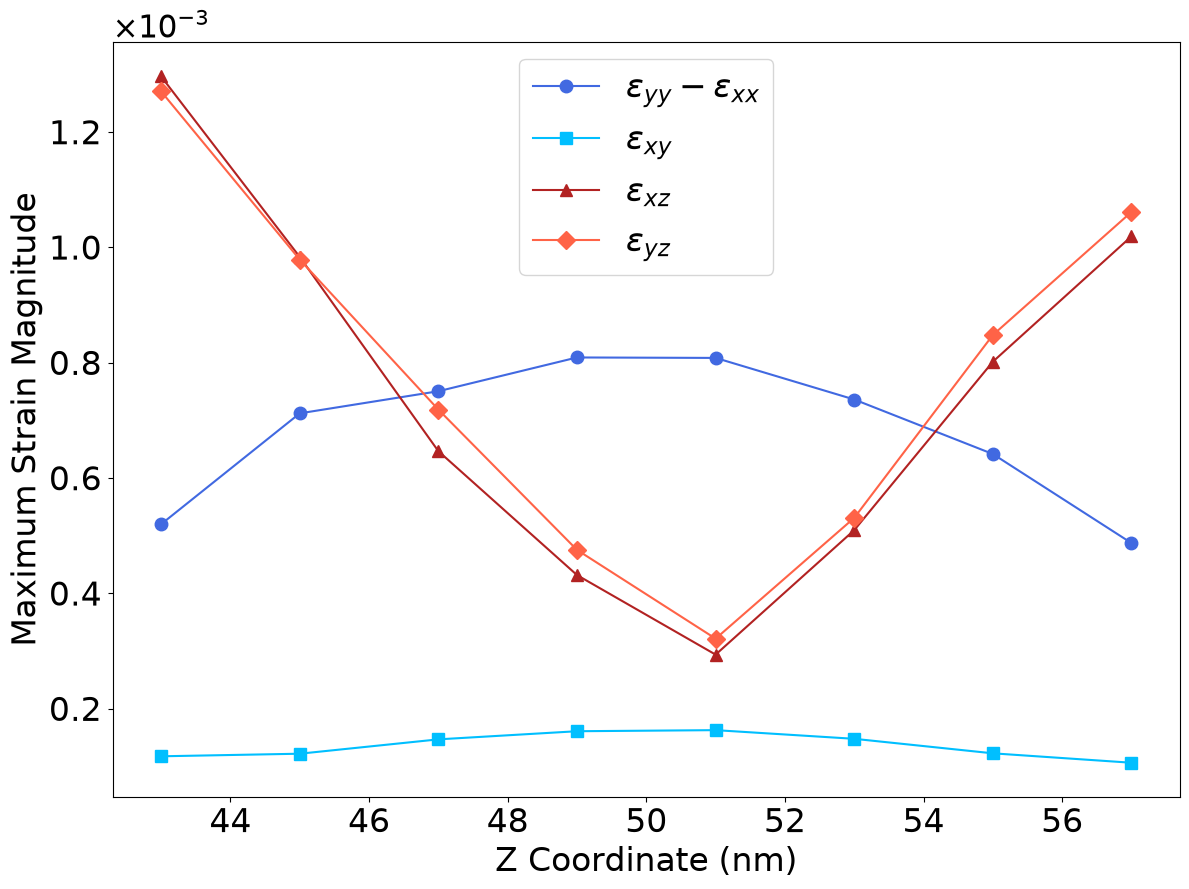

In [27]:
# Variables to control font sizes, legend size, marker size, and scientific notation size
axis_label_size = 24  # Font size for axis labels
tick_label_size = 24  # Font size for tick labels
legend_size = 24      # Font size for the legend
marker_size = 9       # Size of the markers
scientific_notation_size = 22  # Font size for scientific notation multiplier

# Define the color scheme
inplane_color1 = 'royalblue'    # Darker blue for in-plane
inplane_color2 = 'deepskyblue' # Lighter blue for in-plane
outofplane_color1 = 'firebrick' # Darker red for out-of-plane
outofplane_color2 = 'tomato'    # Lighter red for out-of-plane

# Initialize a dictionary to store the maximum strain magnitude for each component
max_strains = {name: [] for name in strain_data.keys()}

# Compute the maximum strain magnitude for each subset
for name, subsets in strain_subsets.items():
    for subset in subsets:
        # Compute the maximum magnitude of strain values in the subset
        max_value = subset['strain_value'].abs().max()
        max_strains[name].append(max_value)

# Create a figure to plot the maximum strain magnitudes
fig, ax = plt.subplots(figsize=(12, 9))

# Define labels for each strain component
labels = {
    'strain_yymxx': r'$\epsilon_{yy} - \epsilon_{xx}$',
    'strain_xz': r'$\epsilon_{xz}$',
    'strain_yz': r'$\epsilon_{yz}$',
    'strain_xy': r'$\epsilon_{xy}$'
}

# Define x-axis values (midpoints of the Z ranges)
z_midpoints = [(z_lower + z_upper) / 2 for z_lower, z_upper in z_ranges]

# Plot maximum strain magnitudes for each component with the specified color scheme
ax.plot(z_midpoints, max_strains['strain_yymxx'], marker='o', markersize=marker_size, label=labels['strain_yymxx'], color=inplane_color1)
ax.plot(z_midpoints, max_strains['strain_xy'], marker='s', markersize=marker_size, label=labels['strain_xy'], color=inplane_color2)
ax.plot(z_midpoints, max_strains['strain_xz'], marker='^', markersize=marker_size, label=labels['strain_xz'], color=outofplane_color1)
ax.plot(z_midpoints, max_strains['strain_yz'], marker='D', markersize=marker_size, label=labels['strain_yz'], color=outofplane_color2)

# Customize the plot
ax.set_xlabel('Z Coordinate (nm)', fontsize=axis_label_size)
ax.set_ylabel('Maximum Strain Magnitude', fontsize=axis_label_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_size)

# Enable scientific notation for y-axis ticks
ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))

# Make the scientific notation multiplier larger
ax.yaxis.get_offset_text().set_fontsize(scientific_notation_size)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot as a PDF
plt.savefig(os.path.join(GRAPH_DIR, "maximum_strain_magnitudes.pdf"), format="pdf")

# Show the plot
plt.show()


In [28]:
# Download the saved PDF file (Google Colab only — on a local machine the
# PDF is already saved under GRAPH_DIR, so no download is needed)
# from google.colab import files
# files.download(os.path.join(GRAPH_DIR, "strain_subset_to_global_ratio.pdf"))

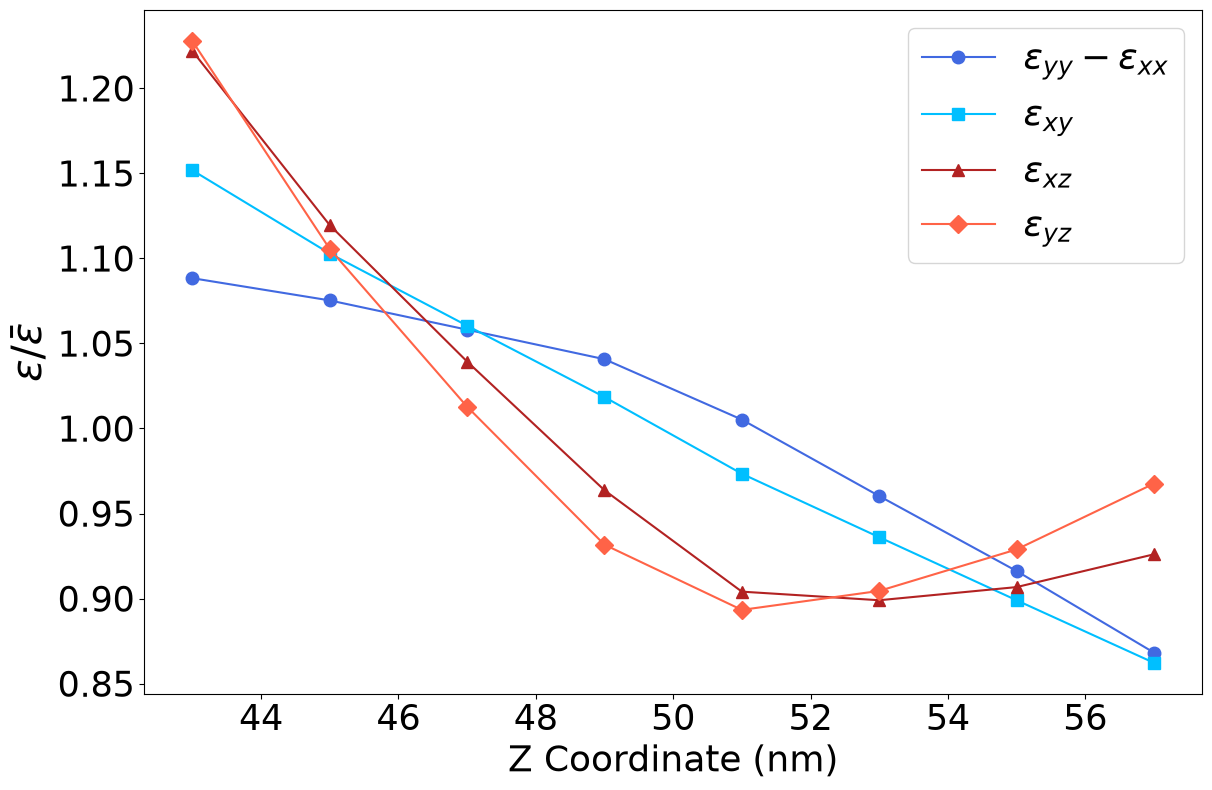

In [29]:
# Variables to control font sizes, legend size, marker size, and scientific notation size
axis_label_size = 26  # Font size for axis labels
tick_label_size = 25  # Font size for tick labels
legend_size = 26      # Font size for the legend
marker_size = 9       # Size of the markers
scientific_notation_size = 22  # Font size for scientific notation multiplier

# Define the color scheme
inplane_color1 = 'royalblue'    # Darker blue for in-plane
inplane_color2 = 'deepskyblue' # Lighter blue for in-plane
outofplane_color1 = 'firebrick' # Darker red for out-of-plane
outofplane_color2 = 'tomato'    # Lighter red for out-of-plane

# Calculate the average magnitude of strain in the entire dataset for each strain component
global_avg_strains = {
    name: df['strain_value'].abs().mean()
    for name, df in strain_data.items()
}

# Initialize a dictionary to store the subset-to-global ratio for each strain component
subset_ratios = {name: [] for name in strain_data.keys()}

# Compute the subset-to-global ratio for each subset
for name, subsets in strain_subsets.items():
    for subset in subsets:
        # Compute the mean magnitude of strain in the subset
        subset_avg = subset['strain_value'].abs().mean()
        # Compute the ratio of subset mean to global mean
        ratio = subset_avg / global_avg_strains[name]
        subset_ratios[name].append(ratio)

# Create a figure to plot the subset-to-global ratios
fig, ax = plt.subplots(figsize=(12, 8))

# Define labels for each strain component
labels = {
    'strain_yymxx': r'$\epsilon_{yy} - \epsilon_{xx}$',
    'strain_xz': r'$\epsilon_{xz}$',
    'strain_yz': r'$\epsilon_{yz}$',
    'strain_xy': r'$\epsilon_{xy}$'
}

# Define x-axis values (midpoints of the Z ranges)
z_midpoints = [(z_lower + z_upper) / 2 for z_lower, z_upper in z_ranges]

# Plot subset-to-global ratios for each component with the specified color scheme
ax.plot(z_midpoints, subset_ratios['strain_yymxx'], marker='o', markersize=marker_size, label=labels['strain_yymxx'], color=inplane_color1)
ax.plot(z_midpoints, subset_ratios['strain_xy'], marker='s', markersize=marker_size, label=labels['strain_xy'], color=inplane_color2)
ax.plot(z_midpoints, subset_ratios['strain_xz'], marker='^', markersize=marker_size, label=labels['strain_xz'], color=outofplane_color1)
ax.plot(z_midpoints, subset_ratios['strain_yz'], marker='D', markersize=marker_size, label=labels['strain_yz'], color=outofplane_color2)

# Customize the plot
ax.set_xlabel('Z Coordinate (nm)', fontsize=axis_label_size)
ax.set_ylabel(r'$\epsilon / \bar{\epsilon}$', fontsize=axis_label_size+4)  # Updated y-axis label
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_size)

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot as a PDF
plt.savefig(os.path.join(GRAPH_DIR, "strain_subset_to_global_ratio.pdf"), format="pdf")

# Show the plot
plt.show()
